# SASHIMI-W: explicit ITAMAE migration choices

This compact notebook compares the unchanged public SASHIMI-W API with three explicit ITAMAE configurations. It is a migration smoke test, not a production-resolution forecast.

- **legacy-q5** reproduces the published implementation.
- **consistent-q5** changes growth, derivative, and mass-unit handling while retaining the published q5 power suppression.
- **consistent-q10** additionally uses the standard transfer-squared power suppression.

The q5/q10 choice is intentionally independent of `physics_mode`. Standard q10 can materially change abundances and is therefore explicit opt-in rather than a silent replacement.

In [1]:
from time import perf_counter

from IPython.display import Markdown, display
import matplotlib.pyplot as plt
import numpy as np

from sashimi_w import subhalos as LegacySubhalos
from sashimi_w_itamae import subhalos as ItamaeSubhalos
from sashimi_w_itamae_migration import PUBLISHED_Q5, STANDARD_T2_Q10

get_ipython().run_line_magic("matplotlib", "inline")
plt.style.use("seaborn-v0_8-whitegrid")

## Public boundary

| Path | Construction | Catalog call | Return contract |
|---|---|---|---|
| Existing public API | `LegacySubhalos(mass_wdm)` | `rs_rhos_calc(...)` | 10-array tuple; radii in kpc and densities in $M_\odot/\mathrm{pc}^3$ |
| ITAMAE opt-in | `ItamaeSubhalos(..., physics_mode=..., wdm_power_convention=...)` | `rs_rhos_catalog_calc(...)` | `WeightedSubhaloCatalog`; canonical Mpc and $M_\odot/\mathrm{Mpc}^3$, factorized weights, metadata |

The historical convenience methods `subhalo_distr(...)` and `N_sat(...)` remain inherited. Regression tests compare those methods directly between the true public class and `legacy-q5`.

In [2]:
mass_wdm = 2.0  # keV
catalog_parameters = {
    "M0": 1.0e10,
    "redshift": 0.0,
    "dz": 0.5,
    "zmax": 1.0,
    "N_ma": 4,
    "sigmalogc": 0.128,
    "N_herm": 2,
    "logmamin": 6.0,
    "logmamax": 8.0,
    "sigmafac": 0.0,
    "N_hermNa": 3,
    "profile_change": True,
}

legacy_public = LegacySubhalos(mass_wdm=mass_wdm)
models = {
    "legacy-q5": ItamaeSubhalos(
        mass_wdm=mass_wdm,
        physics_mode="legacy",
        wdm_power_convention=PUBLISHED_Q5,
    ),
    "consistent-q5": ItamaeSubhalos(
        mass_wdm=mass_wdm,
        physics_mode="consistent",
        wdm_power_convention=PUBLISHED_Q5,
    ),
    "consistent-q10": ItamaeSubhalos(
        mass_wdm=mass_wdm,
        physics_mode="consistent",
        wdm_power_convention=STANDARD_T2_Q10,
    ),
}

print(f"Compact grid: {catalog_parameters['N_ma']} masses × "
      f"{catalog_parameters['N_herm']} concentration nodes × 2 redshifts")

Compact grid: 4 masses × 2 concentration nodes × 2 redshifts


## Compute catalogs and verify historical parity

The public tuple is evaluated independently. The migrated `legacy-q5` catalog must reproduce its numerical columns after the documented unit conversion; its population and concentration factors must multiply back to the historical `weight`.

This notebook deliberately uses the reviewed nonnegative golden grid. Some denser legacy grids expose small non-monotonic oscillations in the historical sharp-$k$ variance derivative and therefore signed accretion weights. The tuple API preserves them for reproduction, while `WeightedSubhaloCatalog` rejects them rather than clipping or silently renormalizing a physical count.

In [3]:
started = perf_counter()
public_tuple = legacy_public.rs_rhos_calc(**catalog_parameters)
catalogs = {
    label: model.rs_rhos_catalog_calc(**catalog_parameters)
    for label, model in models.items()
}
catalog_seconds = perf_counter() - started

legacy_catalog = catalogs["legacy-q5"]
column_checks = {
    "m200_acc": (public_tuple[0], 1.0),
    "z_acc": (public_tuple[1], 1.0),
    "r_s_acc": (public_tuple[2], 1.0e-3),
    "rho_s_acc": (public_tuple[3], 1.0e18),
    "m_bound": (public_tuple[4], 1.0),
    "r_s": (public_tuple[5], 1.0e-3),
    "rho_s": (public_tuple[6], 1.0e18),
    "c_t": (public_tuple[7], 1.0),
}
for name, (legacy_values, scale) in column_checks.items():
    np.testing.assert_allclose(
        legacy_catalog.columns[name],
        np.asarray(legacy_values) * scale,
        rtol=2.0e-9,
        atol=1.0e-13,
    )
np.testing.assert_array_equal(legacy_catalog.columns["survive"], public_tuple[9])
legacy_population_weight = (
    legacy_catalog.weights["weight_base"]
    * legacy_catalog.weights["weight_concentration"]
)
np.testing.assert_allclose(
    legacy_population_weight,
    public_tuple[8],
    rtol=5.0e-12,
    atol=1.0e-100,
)

print(f"legacy-q5 parity: PASS ({legacy_catalog.shape[0]} catalog rows)")
print(f"four compact catalog evaluations: {catalog_seconds:.2f} s")

legacy-q5 parity: PASS (16 catalog rows)
four compact catalog evaluations: 16.92 s


## Physical summary

`N_population` matches the historical convention and excludes the binary survival factor. `N_surviving` uses ITAMAE's `weight_final` and therefore includes it. Ratios are relative to the complete historical `legacy-q5` model.

In [4]:
def population_weight(catalog):
    return catalog.weights["weight_base"] * catalog.weights["weight_concentration"]


reference_population = float(np.sum(population_weight(catalogs["legacy-q5"])))
table_lines = [
    "| mode | physics | power | q | $k_{hm}$ [$h$/Mpc] | $N_{population}$ | ratio | $N_{surviving}$ |",
    "|---|---|---|---:|---:|---:|---:|---:|",
]
for label, catalog in catalogs.items():
    metadata = catalog.metadata
    n_population = float(np.sum(population_weight(catalog)))
    n_surviving = float(np.sum(catalog.weight_final))
    table_lines.append(
        f"| {label} | {metadata['physics_mode']} | "
        f"{metadata['wdm_power_convention']} | {metadata['wdm_power_q']:.0f} | "
        f"{metadata['half_mode_wavenumber_h_per_mpc']:.3g} | "
        f"{n_population:.6e} | {n_population / reference_population:.6e} | "
        f"{n_surviving:.6e} |"
    )

display(Markdown("\n".join(table_lines)))

preview_columns = ("m200_acc", "z_acc", "m_bound", "r_s", "c_t")
preview_rows = []
for index in range(min(6, len(legacy_catalog))):
    preview_rows.append(
        tuple(
            [f"{float(legacy_catalog.columns[name][index]):.5g}" for name in preview_columns]
            + [f"{legacy_catalog.weight_final[index]:.5g}"]
        )
    )
preview_lines = [
    "\nFirst rows of the migrated legacy weighted catalogue:",
    "",
    "| " + " | ".join((*preview_columns, "weight_final")) + " |",
    "|" + "---:|" * (len(preview_columns) + 1),
    *["| " + " | ".join(row) + " |" for row in preview_rows],
]
display(Markdown("\n".join(preview_lines)))

| mode | physics | power | q | $k_{hm}$ [$h$/Mpc] | $N_{population}$ | ratio | $N_{surviving}$ |
|---|---|---|---:|---:|---:|---:|---:|
| legacy-q5 | legacy | published-q5 | 5 | 20.1 | 2.075811e-02 | 1.000000e+00 | 2.075811e-02 |
| consistent-q5 | consistent | published-q5 | 5 | 20.1 | 3.782744e-03 | 1.822296e-01 | 3.782744e-03 |
| consistent-q10 | consistent | standard-t2-q10 | 10 | 20.1 | 2.187179e-06 | 1.053650e-04 | 2.187179e-06 |


First rows of the migrated legacy weighted catalogue:

| m200_acc | z_acc | m_bound | r_s | c_t | weight_final |
|---:|---:|---:|---:|---:|---:|
| 1e+06 | 0.5 | 3.4735e+05 | 0.00054244 | 1.6873 | -0 |
| 4.6416e+06 | 0.5 | 1.5952e+06 | 0.00074595 | 2.0144 | 2.7667e-09 |
| 2.1544e+07 | 0.5 | 7.3258e+06 | 0.0010001 | 2.4583 | 0.00028619 |
| 1e+08 | 0.5 | 3.362e+07 | 0.001282 | 3.118 | 0.0059965 |
| 1e+06 | 0.5 | 3.4735e+05 | 0.00030085 | 2.8959 | -0 |
| 4.6416e+06 | 0.5 | 1.5952e+06 | 0.00041372 | 3.443 | 2.7667e-09 |

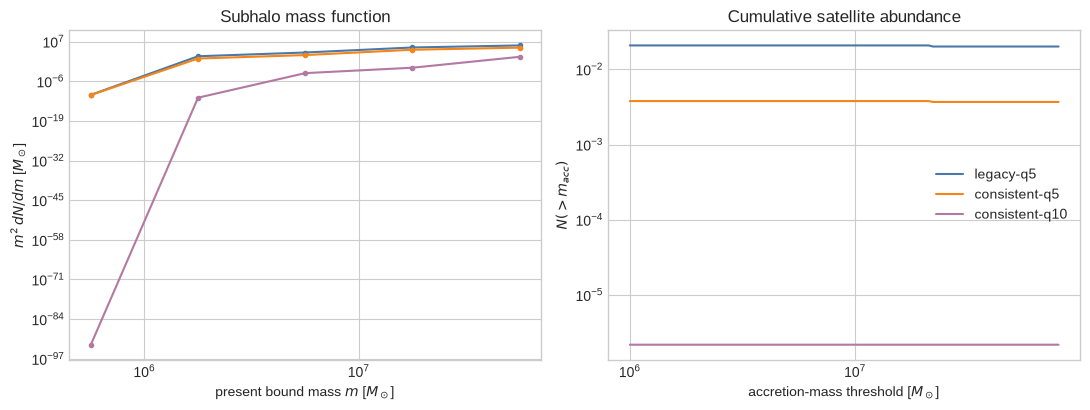

In [5]:
colors = {
    "legacy-q5": "#4c78a8",
    "consistent-q5": "#f58518",
    "consistent-q10": "#b279a2",
}
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

mass_edges = np.geomspace(1.0e4, 1.0e8, 9)
thresholds = np.geomspace(1.0e6, 8.0e7, 100)
for label, catalog in catalogs.items():
    weights = population_weight(catalog)
    bound_mass = catalog.columns["m_bound"]
    counts, edges = np.histogram(bound_mass, bins=mass_edges, weights=weights)
    centers = np.sqrt(edges[:-1] * edges[1:])
    dndm = counts / np.diff(edges)
    positive = dndm > 0.0
    axes[0].loglog(
        centers[positive],
        (centers**2 * dndm)[positive],
        marker="o",
        ms=3,
        label=label,
        color=colors[label],
    )

    accretion_mass = catalog.columns["m200_acc"]
    cumulative = np.asarray([
        np.sum(weights[accretion_mass > threshold]) for threshold in thresholds
    ])
    positive = cumulative > 0.0
    axes[1].loglog(
        thresholds[positive],
        cumulative[positive],
        label=label,
        color=colors[label],
    )

axes[0].set_xlabel(r"present bound mass $m$ [$M_\odot$]")
axes[0].set_ylabel(r"$m^2\,dN/dm$ [$M_\odot$]")
axes[0].set_title("Subhalo mass function")
axes[1].set_xlabel(r"accretion-mass threshold [$M_\odot$]")
axes[1].set_ylabel(r"$N(>m_{acc})$")
axes[1].set_title("Cumulative satellite abundance")
axes[1].legend(frameon=False)
fig.tight_layout()
plt.show()

## Sample-style WDM figures

This section uses the sample notebook's 1.5 keV WDM particle and $10^{12}\,M_\odot$ host, with a reduced grid for an interactive migration demo. It reproduces the mass-function, accretion-mass cumulative, and velocity-threshold plots.

In [ ]:
sample_mass_wdm = 1.5
sample_host_mass = 1.0e12
sample_model = ItamaeSubhalos(
    mass_wdm=sample_mass_wdm,
    physics_mode="legacy",
    wdm_power_convention=PUBLISHED_Q5,
)
sample_plot_parameters = {
    "redshift": 0.0,
    "dz": 0.25,
    "zmax": 2.0,
    "N_ma": 32,
    "sigmalogc": 0.128,
    "N_herm": 3,
    "logmamin": 6.0,
    "logmamax": 11.0,
    "sigmafac": 0.0,
    "N_hermNa": 16,
    "profile_change": True,
}

mass, dndm = sample_model.subhalo_distr(
    sample_host_mass, **sample_plot_parameters
)
number_by_mass, accretion_mass, cumulative_mass = sample_model.N_sat(
    sample_host_mass, **sample_plot_parameters
)
number_by_velocity, vmax, cumulative_velocity = sample_model.N_sat_Vthres(
    sample_host_mass, 18.0, **sample_plot_parameters
)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))
axes[0].loglog(mass, mass**2 * dndm)
axes[0].set(
    xlim=(1.0e6, 1.0e12),
    ylim=(1.0e8, 1.0e11),
    xlabel=r"$m_0$ [$M_\odot$]",
    ylabel=r"$m^2dN_{\rm sh}/dm$ [$M_\odot$]",
    title=rf"$m_{{\rm WDM}}={sample_mass_wdm:g}$ keV",
)
axes[1].loglog(accretion_mass, cumulative_mass)
axes[1].set(
    xlim=(1.0e7, 1.0e11),
    ylim=(1.0, 1.0e3),
    xlabel=r"$m_a$ [$M_\odot$]",
    ylabel=r"$N_{\rm sat}(>m_a)$",
    title=f"Total satellites = {int(number_by_mass)}",
)
valid_velocity = (vmax > 0.0) & (cumulative_velocity > 0.0)
axes[2].loglog(vmax[valid_velocity], cumulative_velocity[valid_velocity])
axes[2].set(
    xlim=(1.0, 70.0),
    ylim=(1.0e-1, 1.0e3),
    xlabel=r"$V_{\rm max}$ [km s$^{-1}$]",
    ylabel=r"$N_{\rm sh}(>V_{\rm max})$",
    title=rf"$V_{{\rm peak}}>18$ km s$^{{-1}}$; total = {int(number_by_velocity)}",
)
fig.tight_layout()
plt.show()

## Structured metadata prevents accidental mixing

The result carries enough information to distinguish the formula role, exponent, half-mode definition, cosmology, units, and growth convention. A q10 catalog cannot be mistaken for a published q5 catalog merely because their numerical half-mode wavenumbers coincide.

In [6]:
metadata_keys = [
    "model_identifier",
    "physics_mode",
    "wdm_power_convention",
    "wdm_power_formula_role",
    "wdm_power_q",
    "half_mode_definition",
    "half_mode_power_ratio",
    "half_mode_wavenumber_h_per_mpc",
    "variance_mass_unit",
    "accretion_mass_redshift_mapping",
    "population_weight_contract",
]
{key: catalogs["consistent-q10"].metadata[key] for key in metadata_keys}

{'model_identifier': 'sashimi-w:wdm:m_wdm_keV=2:physics=consistent:power=standard-t2-q10:itamae-migration:v5',
 'physics_mode': 'consistent',
 'wdm_power_convention': 'standard-t2-q10',
 'wdm_power_formula_role': 'viel-transfer-amplitude-squared',
 'wdm_power_q': 10.0,
 'half_mode_definition': 'T_WDM/T_CDM=0.5;P_WDM/P_CDM=0.25',
 'half_mode_power_ratio': 0.25,
 'half_mode_wavenumber_h_per_mpc': 20.114255416329843,
 'variance_mass_unit': 'Msun',
 'accretion_mass_redshift_mapping': 'per-redshift-virial-mass-grid',
 'population_weight_contract': 'nonnegative-corrected-counts'}

## Interpretation

1. **Published reproduction is an explicit pair:** use `physics_mode="legacy"` together with `wdm_power_convention="published-q5"`. The independent public tuple and migrated catalog agree after unit conversion.
2. **Consistent q5 isolates the migration corrections:** differences from legacy-q5 come from growth normalization, $dS/dM$, physical-mass boundaries, and using the matching virial-mass grid at each accretion redshift—not from changing the WDM power formula.
3. **Consistent q10 is a distinct physical model:** squaring the transfer amplitude suppresses small-scale power more strongly and can change the predicted abundance by orders of magnitude. This reviewed difference is expected, which is why q10 remains explicit opt-in and is recorded in every catalog.